In [ ]:
# Set run type - Allows user to run code in DEMO state (using dummy dataset) or Full Version, accessing resources from Google Colab
# Set 'ON' to run Demo version, 'OFF' to run Full Version (need access to Google Colab resources)
import os
os.environ['RUN_DEMO'] = 'ON' 

## Libraries and Imports

In [ ]:
import src.config as c
import src.load_data as ld
viirs_files = ld.get_filepaths('VIIRS')
viirs_to_load = ld.to_load_viirs(viirs_files,[2018])
viirs_to_load

In [1]:
print(f"\t⚠️ Please note: Currently requesting data from Google EE. Please check GoogleDrive to ensure the requested data is available\n\tGoogle EE request may take hrs/days ")

	⚠️ Please note: Currently requesting data from Google EE. Please check GoogleDrive to ensure the requested data is available
	Google EE request may take hrs/days 


In [ ]:
import src.load_data as ld

In [ ]:
# import sys
# import os

# # Set working directory and mount GoogleDrive
# drive.mount('/content/drive')
# wd = '/content/drive/MyDrive/Colab Notebooks/WildFirePrediction/[2]ProgramWildFirePredict'
# if os.path.exists(wd):
#   print(f"✅  Success - working directory (wd) set as [{wd}]")
# else:
#   print(f"❌ Error: Could not set [{wd}] as root directory for project. Review path and try again...")
# sys.path.append(wd)

In [ ]:
import pandas as pd

d1 = {'lon':     [1,            2,             3,           4,            5],
      'lat':     [10,           11             ,12,         13,           14],
      'date':    ['2024-01-01', '2024-02-02', '2024-03-03', '2024-04-04', '2024-05-05'],
      'another': [0.1,          0.2,           0.3,         0.4,           0.5]}

d2 = {'lon':     [1,            3,            9,            4,            5],
      'lat':     [10,           11,           12,           20,           14],
      'date':    ['2024-01-01', '2024-02-02', '2025-03-03', '2024-04-04', '2024-05-05'],
      'another': [0.1,          0.2,           0.3,          0.4,          0.101]}
                 
de = {'lon':     [1,            2,             3,           4,            5,             3,           9,            4          ],
      'lat':     [10,           11             ,12,         13,           14,            11,          12,           20         ],
      'date':    ['2024-01-01', '2024-02-02', '2024-03-03', '2024-04-04', '2024-05-05',  '2024-02-02','2025-03-03', '2024-04-04'],
      'another': [0.1,          0.2,           0.3,         0.4,           0.5,          0.2,          0.3,          0.4       ]}

cols_merge = ['lon','lat','date']
df1 = pd.DataFrame(d1)
df2 = pd.DataFrame(d2)

df_diff = df2.loc[ ~df2.set_index(cols_merge).index.isin(df1.set_index(cols_merge).index)]
df_diff

df_merged = pd.concat([df1,df_diff], ignore_index=True)
df_merged.shape[0]


In [4]:
import os
os.environ.setdefault("RUN_DEMO", "ON")
import src.config as c
import src.load_data as ld
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import utils as u

# --------------------------
# VARIABLES
# --------------------------
YEAR_FILTER = [2019]
CRS = "EPSG: 4326"          # Set Coordinate Reference System (CRS) so it is uniform across all data inputs
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"     
DATA_DIR        = os.environ.get("DATA_DIR")    
# --------------------------
# VIIRS DATA
# --------------------------
viirs_dict = ld.viirs_load_pipeline(dir_name = 'VIIRS',
                                    crs = CRS,
                                    date_range = YEAR_FILTER)
df_viirs = viirs_dict.get('df_viirs')
print(f"{'='*80}")
print(f"VIIRS Data")
print(f"\tData Type: {type(df_viirs)}")
print(f"\t📅 Date Range: {df_viirs['acq_date'].min()} to {df_viirs['acq_date'].max()}")


# --------------------------
# UK GRID 
# --------------------------
df_uk_grid = ld.load_uk_grid(file_name='ukcp18-uk-land-12km.shp',
                             crs=CRS)
print(f"{'='*80}")
print(f"UK Grid")
print(f"Shape: {df_uk_grid.shape}")

# Grids by Day
print(f"{'='*80}")
print(f"UK Grid Daily")
dates = u.extract_year_range(df_viirs)
df_daily_grid = df_uk_grid.copy()
df_daily_grid['join_key'] = 1
df_daily_grid = df_daily_grid.merge(dates, on='join_key').drop(columns='join_key')
print(f"Shape: {df_daily_grid.shape}")
print(f"Columns: {df_daily_grid.columns}")



VIIRS Data
	Data Type: <class 'geopandas.geodataframe.GeoDataFrame'>
	📅 Date Range: 2019-01-01 to 2019-12-31
UK Grid
Shape: (1692, 4)
UK Grid Daily
Shape: (617580, 5)
Columns: Index(['id', 'x_coord', 'y_coord', 'geometry', 'date'], dtype='object')


In [ ]:
uk_grid_sample = df_daily_grid[(df_daily_grid['date'] >= '2019-01-01') &
                               (df_daily_grid['date'] <= '2019-01-15')
                               ]
#uk_grid_sample.explore()
uk_grid_sample.head()
uk_grid_sample['date'].unique()
uk_grid_sample.shape

In [ ]:
import ee       
try: 
    #ee.Initialize()
    ee.Initialize(project="ee-enmanuelmorego")
except:
    ee.Authenticate()
    #ee.Initialize()

    ee.Initialize(project="ee-enmanuelmorego")

s2 = ee.ImageCollection(SATELITE_IMAGES)

In [ ]:
import pandas as pd
def geodf_to_ee(geo_df: gpd.GeoDataFrame) -> ee.FeatureCollection:
    """
    Convert GeoPandasDataFrame to a GoogleEarth Feature Collection to extract Sentinel-2 images

    Args:
        geo_df (GeoDataFrame): Data frame containing the plygon for the UK Grids, for each date of the date range

    Returns:
        Feature Collection
    """
    features = []
    for _, r in geo_df.iterrows():
        date_f  = r["date"].strftime("%Y-%m-%d")
        coords  = [list(r.geometry.exterior.coords)]
        geom    = ee.Geometry.Polygon(coords)
        feature = ee.Feature(geom,
                             {'date'       : date_f,
                              'grid_id'    : r['id'],
                              'sentinel_id': None,
                              'cloud_pct'  : None})
        features.append(feature)
    return ee.FeatureCollection(features)

def attach_s2_metadata(feature: ee.Feature) -> ee.Feature:
    """
    Takes the Feature of a Feature Collection object constructed from the UK Grid data, and returns
    the metadata for the matching images in Sentinel-2 (sentinel-2 is a global ee variable, defined outside this function)
    - Read FC date
    - Read FC Geometry
    - Find matching images in Sentinel-2
        - Date + 1 day window
        - Overlaps with geometry (Defined UK Grids)
    - Choose one image (least cloudy, better quality, more information)
    - Attach metadata to feature
    """
    # Extract date
    date = ee.Date(feature.get("date"))
    # Extract Geometry
    geom = feature.geometry()
    # Filter Sentinel Class by date and Geometry (location)
    s2_day = (s2
              .filterDate(date, date.advance(1,"day"))
              .filterBounds(geom)
              .sort("CLOUDY_PIXEL_PERCENTAGE"))
    # Choose least cloudy image
    img = s2_day.first()
    # Return results
    return feature.set({"sentinel_id": ee.Algorithms.If(img, img.get("system:id"), None),
                        "cloud_pct":   ee.Algorithms.If(img, img.get("CLOUDY_PIXEL_PERCENTAGE"), None),
                        "has_image":   ee.Algorithms.If(img,1,0)})

# def s2_metadata_to_df(fc: ee.FeatureCollection) -> pd.DataFrame:
#     """
#     Function that takes the feature collection containing the Sentinel-2 Metadata and
#     transforms it into a pandas DataFrame

#     Note:
#         If no data is found for a given grid_id + date, this will be populated with `None` and dealt
#         with at a later stage

#     Args:
#         fc (Feature collection): Contained S2 metadata

#     Returns:
#         df (dataframe): {date, grid_id, sentinel_id, cloud_pct}
#     """
#     fc_info = fc.getInfo()
#     rows = []
#     for f in fc_info['features']:
#         properties          = f['properties']
#         row = {"date"       : properties["date"],
#                "grid_id"    : properties["grid_id"],
#                "sentinel_id": properties.get("s2_id"),
#                "cloud_pct"  : properties.get("cloud_pct")}
#         rows.append(row)
#     df_out = pd.DataFrame(rows)
#     return df_out


In [ ]:
from datetime import datetime
start, end = (uk_grid_sample['date'].min()).strftime('%Y%m%d'), (uk_grid_sample['date'].max()).strftime('%Y%m%d')
fname = f"{start}-{end}_sentinel_images_layer1"

fc_uk_grid = geodf_to_ee(uk_grid_sample)
# Get Sentinel-2 Archive (this is set as a Global ee Variable, therefore, no need to pass in function below - it'll be visible to the function)
s2 = ee.ImageCollection(SATELITE_IMAGES)
fc_w_s2 = fc_uk_grid.map(attach_s2_metadata)

fc_export_test = (fc_w_s2
                  .filter(ee.Filter.eq("has_image",1))
                  .select(['date','grid_id','sentinel_id','cloud_pct'])
                  .map(lambda f: f.setGeometry(None))
                  .limit(3)) # Test line

export_dict = fc_export_test.getInfo()
features = export_dict.get("features", [])
print(export_dict)
print(features)
for f in features:
    props = f.get("properties", {})
    if "sentinel_id" in props and "cloud_pct" in props:
        succesful_conn = True
        break

if succesful_conn:
    print("✅  Success..! Moving to actual csv export")
    fc_export = (fc_w_s2
                 .filter(ee.Filter.eq("has_image",1))
                 .select(['date','grid_id','sentinel_id','cloud_pct'])
                 .map(lambda f: f.setGeometry(None)))
    task = ee.batch.Export.table.toDrive(collection=fc_export,
                                     description=fname,
                                     folder = "Sentinel2",
                                     fileFormat="CSV")
    task.start()
    task.status()
else:
    print("❌ Error - unable to establish connection with GoogleEarthEngine and fetch Sentinel Data")    




In [ ]:
import pandas as pd

sentinel_fname = Path(os.environ.get('DATA_DIR'))/"Sentinel2"/"20190101-20190115_sentinel_images_layer1.csv"
df_sentinel = pd.read_csv(sentinel_fname)

df_sent_unique = df_sentinel.drop_duplicates(subset='grid_id')
df_sent_unique

In [ ]:
row = df_sentinel.iloc[9996]  # or sample(1).iloc[0]
row = df_sentinel[df_sentinel['cloud_pct'] == df_sentinel['cloud_pct'].min()]
row = row.iloc[1]

sentinel_id = row["sentinel_id"]
grid_id = row["grid_id"]
date = row["date"]
cloud = row['cloud_pct']

print(f"Grid {grid_id} Sentinel id {sentinel_id} Date {date} Cloud {cloud}")

In [ ]:
import ee
import geemap

img = ee.Image(sentinel_id)

In [ ]:
# Clip sentinel image to 12x12km grid
grid_geom = df_uk_grid.loc[df_uk_grid["id"] == grid_id].geometry.iloc[0]
ee_geom = ee.Geometry.Polygon(list(grid_geom.exterior.coords))
chip = img.clip(ee_geom)



In [ ]:
Map = geemap.Map()

vis = {
    "bands": ["B4", "B3", "B2"],  # RGB
    "min": 0,
    "max": 2000,
    "gamma": 1.2
}

Map.addLayer(chip, vis, f"Grid {grid_id}")
Map.addLayer(ee_geom, {}, "Grid boundary")
Map.centerObject(ee_geom, 9)
Map


In [ ]:
uk_geom = ee.Geometry.Polygon(
    list(df_uk_grid.geometry.iloc[0].exterior.coords)
)
s2_uk = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2019-01-01", "2019-01-31")
    .filterBounds(uk_geom)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 80))  # optional
)
s2_mosaic = s2_uk.mosaic().clip(uk_geom)
import geemap

Map = geemap.Map()

vis = {
    "bands": ["B4", "B3", "B2"],  # true colour
    "min": 200,
    "max": 2000,
    "gamma": 1.2
}

Map.addLayer(s2_mosaic, vis, "Sentinel-2 UK mosaic (Jan 2019)")
Map.centerObject(uk_geom, 5)
Map



Extract infomraitaon from sentinel images for CNN

BANDS = ['B2',']

In [ ]:
BANDS = ["B2","B3","B4","B8"]
# The 12x12km size is too big. downsize to this value so it works better with RESENT and efficient next
# Manatains spatial context 
OUT_SIZE = 224
# Resolution in meters
SCALE = 10

sentinel_id = "COPERNICUS/S2_SR_HARMONIZED/20190101T114501_20190101T114457_T30UVG" # Test only

In [ ]:
# Extract grid chip function
"""
Extract a fixed-size Sentinel-2 chip for one grid cell and date.
Returns an Earth Engine Image ready for export or sampling.
"""
ee_geom = ee.Geometry.Polygon(
    list(grid_geom.exterior.coords)
)
img  = ee.Image(sentinel_id).select(BANDS)
chip = (img
        .clip(grid_geom)
        .reproject(CRS, None, SCALE))

In [ ]:
#chip = extract_grid_chip(sentinel_id, ee_geom)

Map = geemap.Map()
Map.addLayer(
    chip,
    {"bands": ["B4", "B3", "B2"], "min": 300, "max": 1800},
    "Grid chip"
)
Map.addLayer(ee_geom, {}, "Grid boundary")
Map.centerObject(ee_geom, 9)
Map


In [1]:
import math
import load_data as ld
import pandas as pd
import src.load_data as ld

df = pd.DataFrame({'date': ['2025-01-01', '2025-01-04', '2025-01-02', '2025-01-03', '2025-01-01',
                            '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08', '2025-01-09','2025-01-09'],
                       'name': ['a', 'a.1','b', 'c', 'd',
                                'e', 'f',  'g', 'h', 'i', 'i.1']})

required = pd.date_range(start='2025-01-01',
                            end='2025-01-09',
                            freq="D")
required = required.date.tolist()
out = ld.sentinel_batch_create(df, required, 2)
expected = {'batch_1': df.iloc[[0,1,5]],
                'batch_2': df.iloc[2:3],
                'batch_3': df.iloc[4:5],
                'batch_4': df.iloc[6:7],
                'batch_5': df.iloc[8:9],
                'batch_6': df.iloc[10:]}

for key in out:
    print(type(out.get(key)))

⏱️  Google Earth engine will take approximately 0hrs 1mins to process 11 rows of data
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [ ]:
req_files = {'a': [],
             'b': []}

if req_files['b']:
    print("Hey")

In [5]:
import pygrib
fwi_file = Path(DATA_DIR)/"FWI"/"2017FWI.grib"
# Open Grib file
grbs = pygrib.open(fwi_file)
# Inspect available objects
unique_names = sorted({grb.name for grb in grbs})
print(f"Available Objects: {unique_names}\n")

grb_name = unique_names[0]
print(f"Cleaned name: {grb_name}")

Available Objects: ['Forest fire weather index (as defined by the Canadian Forest Service)']

Cleaned name: Forest fire weather index (as defined by the Canadian Forest Service)


In [ ]:
# Extract the data of interest
from datetime import datetime
import pandas as pd
fwi_messages = grbs.select(name=grb_name)
fwi_messages=fwi_messages[360:364]
#fwi_messages = fwi_messages[0:2]
fwi_data = {'longitude': [],
            'latitude': [],
            'fwi': [],
            'date': []}

list_fwi = []
total = len(fwi_messages)
total
i = 1

df_uk_grid = df_uk_grid.rename(columns={'id': 'grid_id'})
# Loop thru each of the messages to extract all of the data 
for grb in fwi_messages:
    print(f"\r...Processing {i} of {total} [{round((i/total)*100,2)}]%", end="")
    date = grb.validDate
    date = datetime.strptime(f"{grb.dataDate}{grb.dataTime:04d}", "%Y%m%d%H%M")
    lats,lons = grb.latlons()
    fwi_values = grb.values
    n = fwi_values.size

    df_grib = pd.DataFrame({"longitude":lons.ravel(),
                            "latitude" : lats.ravel(),
                            "fwi":      fwi_values.ravel(),
                            "date":     [date] * n})
    df_grib["longitude"] = df_grib["longitude"].where(df_grib["longitude"] <= 180,
                                                      df_grib["longitude"] - 360)
    df_grib = df_grib[df_grib['fwi'].notna()]
    df_geo_grib = gpd.GeoDataFrame(df_grib,
                                   geometry=gpd.points_from_xy(df_grib.longitude, 
                                                               df_grib.latitude),
                                   crs = CRS)
  
    df_join = gpd.sjoin(df_geo_grib, df_uk_grid , how = 'inner', predicate = 'within')
    df_grouped = (df_join
                  .groupby(['grid_id','date'], as_index=False)
                  .agg(fwi_max  = ('fwi','max'),
                       fwi_mean = ('fwi','mean'))
             )
    list_fwi.append(df_grouped)

    i += 1

print(f"\n{df_join.shape}")
df_fwi = pd.concat(list_fwi, ignore_index = True)
df_fwi.head()

# df_fwi = pd.DataFrame(fwi_data)
# print(df_fwi['date'].min())
# print(df_fwi['date'].max())


...Processing 4 of 4 [100.0]%
(422, 9)


,grid_id,date,fwi_max,fwi_mean
0,0,2017-12-27,2.734375e-02,2.734375e-02
1,3,2017-12-27,7.314453e-02,7.314453e-02
2,17,2017-12-27,3.339844e-02,3.339844e-02
3,18,2017-12-27,5.566408e-03,5.566408e-03
4,20,2017-12-27,1.915832e-09,1.915832e-09


In [22]:
print(df_grib['longitude'].min())
print(df_grib['latitude'].max())

0.0
89.78487690721863


In [ ]:
df_join.explore()

Download FWI via API
Use same logic of fetching file from API if needed, else, fetch .csv files 

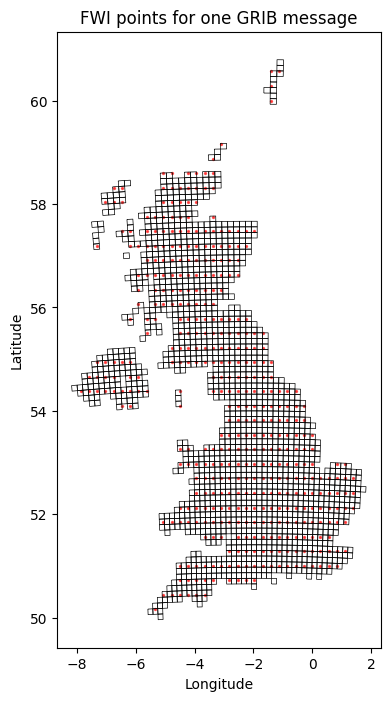

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 8))

# UK grid outline (acts as the "map")
df_uk_grid.boundary.plot(ax=ax, color="black", linewidth=0.5)

# One df_join instance (sample to keep it fast)
df_join.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=0.6
)

ax.set_title("FWI points for one GRIB message")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


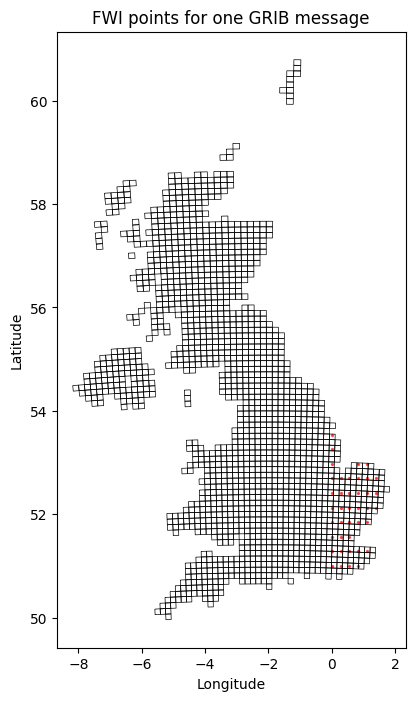

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 8))

# UK grid outline (acts as the "map")
df_uk_grid.boundary.plot(ax=ax, color="black", linewidth=0.5)

# One df_join instance (sample to keep it fast)
df_join.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=0.6
)

ax.set_title("FWI points for one GRIB message")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()
